Using device: cpu
ANN(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)
Epoch [1/5], Loss: 0.3495
Epoch [2/5], Loss: 0.1385
Epoch [3/5], Loss: 0.0957
Epoch [4/5], Loss: 0.0717
Epoch [5/5], Loss: 0.0573
Test Accuracy: 97.36%


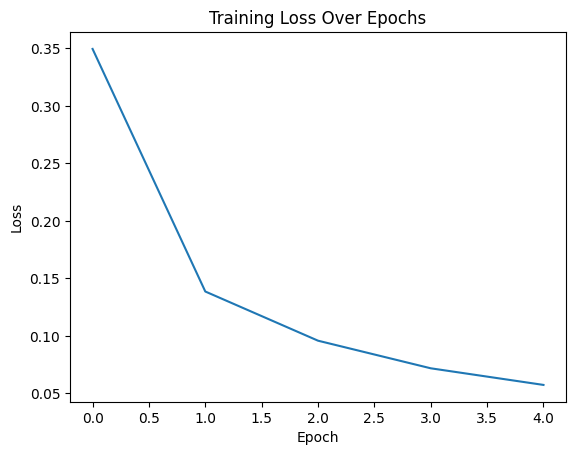

Model saved.


In [ ]:
# Cell 1: Import Libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Load MNIST Dataset
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=1000, shuffle=False)

#  Define the Neural Network
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)  # Flatten the image
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)  # No softmax here; CrossEntropyLoss handles it
        return x

model = ANN().to(device)
print(model)

#  Define Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

#  Train the Model
epochs = 5
train_losses = []

for epoch in range(epochs):
    model.train()
    running_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")


    #  Test the Model
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")


# Plot Training Loss
plt.plot(train_losses)
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()


#  Save the Model (Optional)
torch.save(model.state_dict(), "mnist_ann_model.pth")
print("Model saved.")


In [1]:
import torch

# Create a tensor
x = torch.tensor([[1., 2.], [3., 4.]])
print(x)

# Create random tensor
r = torch.randn(2, 3)

# Add
print(x + x)

# Move to GPU (if available)
if torch.cuda.is_available():
    x = x.to("cuda")


tensor([[1., 2.],
        [3., 4.]])
tensor([[2., 4.],
        [6., 8.]])


In [2]:
x = torch.tensor([2.0], requires_grad=True)
y = x**2 + 3*x + 1
y.backward()
print(x.grad)  # dy/dx = 2x + 3 → 2*2 + 3 = 7


tensor([7.])


In [3]:
import torch.nn as nn
import torch.nn.functional as F

class ANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return self.fc2(x)


In [6]:
import torch

# Eqn :sum of pilog2(pi)
#  3-class distribution
p = torch.tensor([0.5, 0.3, 0.2])

#  Add a small value to avoid log(0)
epsilon = 1e-10
p = p + epsilon

#: Calculate entropy base e
entropy = -torch.sum(p * torch.log(p))

#  Convert to bits base 2
entropy_bits = entropy / torch.log(torch.tensor(2.0))

print("Ent nats:", entropy.item())
print("Ent bits:", entropy_bits.item())



Ent nats: 1.0296530723571777
Ent bits: 1.4854754209518433


In [9]:
import torch
import torch.nn as nn

# Fake output (logits) from a neural net (batch size = 1, 4 classes)
logits = torch.tensor([[1.5, 0.3, 2.1, 0.1]], requires_grad=True)

# Ground truth (class index, not one-hot)
target = torch.tensor([2])  # class index 2 is correct

# Cross-entropy loss
criterion = nn.CrossEntropyLoss()
loss = criterion(logits, target)

print("Cross Entropy Loss:", loss.item())


Cross Entropy Loss: 0.6148861050605774
